In [2]:
import sparse
import h5py
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


In [3]:
ospool_sparse_srm_filename = "job_14965616_stacked_sparse_5d_srm.h5"
ospool_sparse_srm_dir = Path("../")
with h5py.File(ospool_sparse_srm_dir / ospool_sparse_srm_filename, "r") as f:
    ospool_sparse_srm = sparse.COO(
        f['srm/coords'][:], # type: ignore
        f['srm/data'][:], # type: ignore
        shape=tuple(f['srm'].attrs['shape']) # type: ignore
    )

In [24]:
def triangulate_polygons(polygons):
    triangles = []
    for polygon in polygons:
        if len(polygon) < 3:
            continue  # Not enough vertices to form a triangle

        # Triangulate the polygon using a fan triangulation method
        for i in range(1, len(polygon) - 1):
            triangles.append([polygon[0], polygon[i], polygon[i + 1]])

    return np.array(triangles)

def add_mesh_sharp_edges(axs, mesh,*, color="red", linewidth=1.5, alpha=1.0):
    # 1. Find the "sharp" edges to hide flat diagonals
    # face_adjacency_angles gives the angle (in radians) between adjacent triangles.
    # We use > 0.1 radians (~5 degrees) to catch true geometric corners.
    is_sharp = mesh.face_adjacency_angles > 0.1

    # Extract the (N, 2) array of vertex indices that form these sharp edges
    sharp_edges = mesh.face_adjacency_edges[is_sharp]

    v = mesh.vertices

    # Helper function to plot just the sharp line segments in 2D
    def draw_wireframe(ax, coords_2d):
        for edge in sharp_edges:
            # Get the 2D coordinates for the start and end of the edge
            p1 = coords_2d[edge[0]]
            p2 = coords_2d[edge[1]]
            ax.plot([p1[0], p2[0]], [p1[1], p2[1]], color=color, linewidth=linewidth, alpha=alpha)

    # 1. XY Projection (Drop Z)
    draw_wireframe(axs[0], v[:, [0, 1]])

    # 2. XZ Projection (Drop Y)
    draw_wireframe(axs[1], v[:, [0, 2]])

    # 3. YZ Projection (Drop X)
    draw_wireframe(axs[2], v[:, [1, 2]])


def plot_sparse_3d_projections(
    srm_crystal_sparse, id=1, *, prefix:str = "Crystal", fov_size_mm=(100, 100, 100)
):

    # Calculate the projections
    projections = [srm_crystal_sparse.sum(axis=2-i).todense() for i in range(3)]
    extent_indices = [(0, 1), (0, 2), (1, 2)]
    extents = [
        (-fov_size_mm[extent_indices[i][0]] * 0.5, fov_size_mm[extent_indices[i][0]] * 0.5, -fov_size_mm[extent_indices[i][1]] * 0.5, fov_size_mm[extent_indices[i][1]] * 0.5) for i in range(3)
    ]
    axes_titles = ["XY Projection", "XZ Projection", "YZ Projection"]
    axis_labels = [("X-axis", "Y-axis"), ("X-axis", "Z-axis"), ("Y-axis", "Z-axis")]

    # Create a figure with 3 subplots
    fig, axs = plt.subplots(1, 3, figsize=(16, 5))
    ims = []
    for i in range(3):
        ax = axs[i]
        ims.append(ax.imshow(projections[i].T, cmap="hot", interpolation="none", extent=extents[i], origin="lower"))
        ax.set_title(f"{axes_titles[i]} ({prefix} {id})")
        ax.set_xlabel(axis_labels[i][0])
        ax.set_ylabel(axis_labels[i][1])
        ax.set_aspect("equal")
        ax.set_xlim(-400, 400)
        ax.set_ylim(-400, 400)

    axs[2].set_title(f"YZ Projection ({prefix} {id})")
    axs[2].set_xlabel("Y-axis")
    axs[2].set_ylabel("Z-axis")

    fig.colorbar(ims[0], ax=axs, orientation="vertical", fraction=0.02, pad=0.04)
    return fig, axs, ims

In [6]:
import qmirt
import trimesh

meshes =  qmirt.plot.wrl.parse_vrml_indexed_face_sets(Path("../scanner_and_phantom_geometry.wrl"))
print(f"Loaded {len(meshes)} meshes from VRML file.")
# print(meshes[0])  # Print the first mesh for inspection
this_crystal_mesh = next((mesh for mesh in meshes if mesh["name"] == "DetectorCrystal_1:0"), None)

Loaded 347 meshes from VRML file.


In [9]:
def get_mesh_by_name(meshes, name):
    mesh = next(
            (
                mesh
                for mesh in meshes
                if mesh["name"] == name
            ),
            None,
        )
    if mesh is None:
        raise ValueError(f"Mesh with name '{name}' not found.")
    vertices = mesh["vertices"]
    polygons = mesh["polygons"]
    # Convert the parsed polygons into an (m, 3) triangle array
    faces_array = triangulate_polygons(polygons)
    trimesh_mesh = trimesh.Trimesh(
        vertices=vertices,
        faces=faces_array,
        process=True,  # Recommended: merges duplicate vertices and cleans the mesh topology
    )
    return trimesh_mesh

Processing Head ID 1, Row ID 0


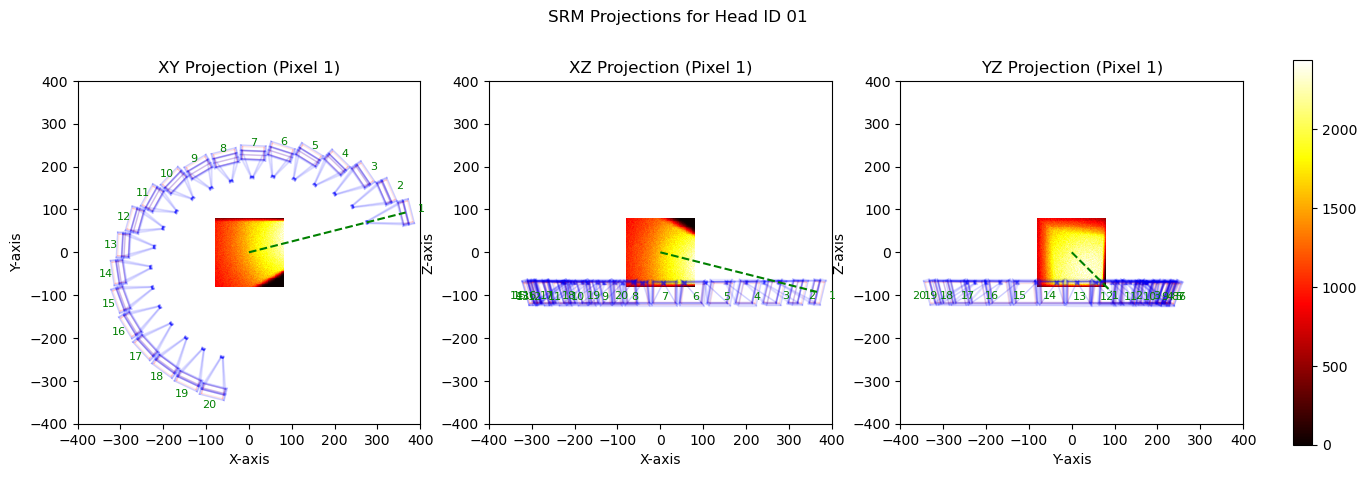

In [26]:
plt.ion()
for head_id in range(1):
    fig, axs, ims = plot_sparse_3d_projections(
        ospool_sparse_srm[head_id].sum(axis=0), id=head_id+1, prefix="Pixel", fov_size_mm=(160, 160, 160)
    )

    centers = []
    head_row_id = head_id // 20
    print(f"Processing Head ID {head_id+1}, Row ID {head_row_id}")
    for crysta_id in range(head_row_id * 20 + 1, (head_row_id + 1) * 20 + 1):
        crystal_mesh_name = f"DetectorCrystal_{crysta_id}:0"
        crystal_mesh = get_mesh_by_name(meshes, crystal_mesh_name)
        collimator_mesh_name = f"Collimator_{crysta_id}:0"
        collimator_mesh = get_mesh_by_name(meshes, collimator_mesh_name)
        add_mesh_sharp_edges(axs, crystal_mesh, color="red", linewidth=1.0, alpha=0.1)
        add_mesh_sharp_edges(axs, collimator_mesh,color="blue", linewidth=1.0, alpha=0.1)
        axes_xyz_id = [[0, 1], [0, 2], [1, 2]]
        center = crystal_mesh.centroid
        centers.append(center)
        
        for axs_id in range(3):
            axs[axs_id].text(
                center[axes_xyz_id[axs_id][0]]*1.1,
                center[axes_xyz_id[axs_id][1]]*1.1,
                f"{crysta_id}",
                color="green",
                fontsize=8,
                ha="center",
                va="center",
            )

    # principal_axes = np.stack([centers[19-(head_id % 20)],np.array([0,0,0])],axis=0)
    principal_axes = np.stack([np.array([0,0,0]), centers[head_id]],axis=0)
    principal_axes_vectors = principal_axes[1] - principal_axes[0]
    for axs_id in range(3):
        axs[axs_id].plot(
                principal_axes[:, axes_xyz_id[axs_id][0]],
                principal_axes[:, axes_xyz_id[axs_id][1]],
                color="green",
                linewidth=1.5,
                linestyle="--",
        )
        

    fig.suptitle(f"SRM Projections for Head ID {(head_id + 1):02}")
    plt.show()
    plt.close(fig)  # Close the figure to free up memory

In [ ]:
def get_dc_spect_geometry_config(
    xlsx_path: Path, stl_dir: Path, *, n_pixels=(25, 25, 1)
) -> dict:
    import pandas as pd
    n_heads = 80
    collimator_hole_size_mm = 2.3  # unit is mm
    collimator_wall_thickness_mm = 2.0  # unit is mm
    collimator_guide_length_mm = 3.0
    detector_crystal_size_mm = [50.0, 50.0, 10.0]  # unit is mm
    n_pixels = np.array(n_pixels)

    pixel_size_mm = detector_crystal_size_mm / n_pixels

    shielding_file_path = (
        stl_dir / "dc_spect_shielding_combined.stl" if stl_dir else None
    )

    df_coords = pd.read_excel(
        xlsx_path, sheet_name="Coordinates"
    )  # read the "Coordinates" sheet
    df_coords.columns = df_coords.iloc[0]
    df_coords = df_coords[1:]  # remove the first row which is now the header
    df_coords = df_coords.reset_index(
        drop=True
    )  # reset the index after removing the first row
    df_coords = df_coords.apply(
        pd.to_numeric, errors="coerce"
    )  # convert all columns to numeric, coercing errors to NaN
    df_coords.columns.name = "Coordinates Sheet"

    collimator_body_length_mm_np = df_coords["length of collimator"].values
    collimator_hole_coords_mm = df_coords[
        [
            "x coordinate value at center of hole",
            "y coordinate value at center of hole",
            "z coordinate value at center of hole",
        ]
    ].values

    # Fail early if the spreadsheet contains non-numeric values in required fields.
    if (
        np.isnan(collimator_body_length_mm_np).any()
        or np.isnan(collimator_hole_coords_mm).any()
    ):
        raise ValueError(
            "Invalid geometry spreadsheet values detected (NaN) in required columns. "
            "Please check the Coordinates sheet numeric fields."
        )

    if not isinstance(collimator_body_length_mm_np, np.ndarray):
        collimator_body_length_mm_np = np.asarray(collimator_body_length_mm_np)

    if not isinstance(collimator_hole_coords_mm, np.ndarray):
        collimator_hole_coords_mm_np = np.asarray(collimator_hole_coords_mm)
    else:
        collimator_hole_coords_mm_np = collimator_hole_coords_mm

    hole_fov_center_distance_mm_np = np.linalg.norm(
        collimator_hole_coords_mm_np, axis=1
    )
    azimuthal_angle_deg = (
        np.arctan2(
            collimator_hole_coords_mm_np[:, 1], collimator_hole_coords_mm_np[:, 0]
        )
        * 180
        / np.pi
    )
    hole_fov_center_dist_xy_mm_np = np.linalg.norm(
        collimator_hole_coords_mm_np[:, :2], axis=1
    )
    polar_angle_deg = (
        np.arctan2(collimator_hole_coords_mm_np[:, 2], hole_fov_center_dist_xy_mm_np)
        * 180
        / np.pi
    )
    collimator_body_center_dist_mm_np = (
        hole_fov_center_distance_mm_np + collimator_body_length_mm_np * 0.5
    )
    collimator_body_translation_mm = collimator_body_center_dist_mm_np.reshape(
        -1, 1
    ) * np.column_stack(
        (
            np.cos(np.radians(polar_angle_deg))
            * np.cos(np.radians(azimuthal_angle_deg)),
            np.cos(np.radians(polar_angle_deg))
            * np.sin(np.radians(azimuthal_angle_deg)),
            np.sin(np.radians(polar_angle_deg)),
        )
    )
    detector_crystal_center_dist_mm_np = (
        hole_fov_center_distance_mm_np
        + collimator_body_length_mm_np
        + detector_crystal_size_mm[2] * 0.5
    )
    detector_crystal_translation_mm = detector_crystal_center_dist_mm_np.reshape(
        -1, 1
    ) * np.column_stack(
        (
            np.cos(np.radians(polar_angle_deg))
            * np.cos(np.radians(azimuthal_angle_deg)),
            np.cos(np.radians(polar_angle_deg))
            * np.sin(np.radians(azimuthal_angle_deg)),
            np.sin(np.radians(polar_angle_deg)),
        )
    )

    collimator_wall_thickness_mm_np = np.full((n_heads,), collimator_wall_thickness_mm)
    collimator_body_inner_top_mm_np = np.full((n_heads,), detector_crystal_size_mm[0])
    collimator_body_inner_bottom_mm_np = np.full((n_heads,), collimator_hole_size_mm)
    collimator_body_outer_top_mm_np = (
        collimator_body_inner_top_mm_np + collimator_wall_thickness_mm_np * 2
    )
    collimator_body_outer_bottom_mm_np = (
        collimator_body_inner_bottom_mm_np + collimator_wall_thickness_mm_np * 2
    )

    collimator_guide_exit_angle_rad = np.arctan2(
        (collimator_body_inner_top_mm_np + collimator_body_inner_bottom_mm_np) * 0.5,
        collimator_body_length_mm_np,
    )

    collimator_guide_length_mm_np = np.full((n_heads,), collimator_guide_length_mm)
    collimator_guide_distance_mm_np = (
        hole_fov_center_distance_mm_np - collimator_guide_length_mm_np
    )
    collimator_guide_translation_mm = collimator_guide_distance_mm_np.reshape(
        -1, 1
    ) * np.column_stack(
        (
            np.cos(np.radians(polar_angle_deg))
            * np.cos(np.radians(azimuthal_angle_deg)),
            np.cos(np.radians(polar_angle_deg))
            * np.sin(np.radians(azimuthal_angle_deg)),
            np.sin(np.radians(polar_angle_deg)),
        )
    )

    collimator_guide_inner_top_mm_np = np.full((n_heads,), collimator_hole_size_mm)
    collimator_guide_outer_top_mm_np = (
        collimator_guide_inner_top_mm_np + collimator_wall_thickness_mm_np * 2
    )
    collimator_guide_inner_bottom_mm_np = (
        collimator_guide_inner_top_mm_np
        + np.tan(collimator_guide_exit_angle_rad) * collimator_guide_length_mm_np * 2
    )
    collimator_guide_outer_bottom_mm_np = (
        collimator_guide_inner_bottom_mm_np + collimator_wall_thickness_mm_np * 2
    )

    return {
        "collimator_body_length_mm_np": collimator_body_length_mm_np,
        "collimator_hole_coords_mm_np": collimator_hole_coords_mm_np,
        "collimator_body_translation_mm": collimator_body_translation_mm,
        "collimator_body_inner_top_mm_np": collimator_body_inner_top_mm_np,
        "collimator_body_inner_bottom_mm_np": collimator_body_inner_bottom_mm_np,
        "collimator_body_outer_top_mm_np": collimator_body_outer_top_mm_np,
        "collimator_body_outer_bottom_mm_np": collimator_body_outer_bottom_mm_np,
        "collimator_guide_length_mm_np": collimator_guide_length_mm_np,
        "collimator_guide_translation_mm": collimator_guide_translation_mm,
        "collimator_guide_inner_top_mm_np": collimator_guide_inner_top_mm_np,
        "collimator_guide_outer_top_mm_np": collimator_guide_outer_top_mm_np,
        "collimator_guide_inner_bottom_mm_np": collimator_guide_inner_bottom_mm_np,
        "collimator_guide_outer_bottom_mm_np": collimator_guide_outer_bottom_mm_np,
        "collimator_wall_thickness_mm": collimator_wall_thickness_mm,
        "detector_crystal_size_mm": detector_crystal_size_mm,
        "pixel_size_mm": pixel_size_mm,
        "n_pixels": n_pixels,
        "detector_crystal_translation_mm": detector_crystal_translation_mm,
        "azimuthal_angle_deg": azimuthal_angle_deg,
        "polar_angle_deg": polar_angle_deg,
        "shielding_file_path": str(shielding_file_path),
    }
dc_spect_geometry_config = get_dc_spect_geometry_config(
    Path("../../../persistent_data/cardiac_spect/spreadsheet/MDSL.excel80M10RFR.cut-plate.010.150roi.2.30pin.105ellipse.xlsx"), Path("../stl_files"))

In [22]:
# Now create a grid of points representing the pixel centers within the crystal volume.
crystal_n_pixels = (1, 25, 25)  # Number of pixels along each axis (X, Y, Z)
detector_crystal_size_mm = (10.0, 50.0, 50.0)
# 1. Calculate the pitch (size of one pixel) for each axis
pitch = [size / n for size, n in zip(detector_crystal_size_mm, crystal_n_pixels)]

# 2. Calculate true pixel centers
# Range is from (-half_size + half_pitch) to (half_size - half_pitch)
x = np.linspace(-detector_crystal_size_mm[0]/2 + pitch[0]/2, 
                 detector_crystal_size_mm[0]/2 - pitch[0]/2, 
                 crystal_n_pixels[0])

y = np.linspace(-detector_crystal_size_mm[1]/2 + pitch[1]/2, 
                 detector_crystal_size_mm[1]/2 - pitch[1]/2, 
                 crystal_n_pixels[1])

z = np.linspace(-detector_crystal_size_mm[2]/2 + pitch[2]/2, 
                 detector_crystal_size_mm[2]/2 - pitch[2]/2, 
                 crystal_n_pixels[2])
X, Y, Z = np.meshgrid(x, y, z, indexing='ij')
# 4. Stack and flatten into an (N, 3) array of coordinates
pixel_centers = np.stack([X, Y, Z], axis=-1)
print(f"Pixel centers shape: {pixel_centers.shape}")


pixel_centers_indices = np.indices(crystal_n_pixels).reshape(3, -1).T  # Shape (N, 3)
print(f"Pixel centers indices shape: {pixel_centers_indices.shape}")
print(f"Pixel centers indices:\n{pixel_centers_indices}")

Pixel centers shape: (1, 25, 25, 3)
Pixel centers indices shape: (625, 3)
Pixel centers indices:
[[ 0  0  0]
 [ 0  0  1]
 [ 0  0  2]
 ...
 [ 0 24 22]
 [ 0 24 23]
 [ 0 24 24]]


In [33]:
def update_sparse_3d_projections(
    ims, sparse_3d_srm, id=1, *, prefix:str = "Crystal", fov_size_mm=(100, 100, 100)
):

    # Calculate the projections
    projections = [sparse_3d_srm.sum(axis=2-i).todense() for i in range(3)]
    extent_indices = [(0, 1), (0, 2), (1, 2)]
    extents = [
        (-fov_size_mm[extent_indices[i][0]] * 0.5, fov_size_mm[extent_indices[i][0]] * 0.5, -fov_size_mm[extent_indices[i][1]] * 0.5, fov_size_mm[extent_indices[i][1]] * 0.5) for i in range(3)
    ]
    axes_titles = ["XY Projection", "XZ Projection", "YZ Projection"]
    axis_labels = [("X-axis", "Y-axis"), ("X-axis", "Z-axis"), ("Y-axis", "Z-axis")]

    # Create a figure with 3 subplots
    fig, axs = plt.subplots(1, 3, figsize=(16, 5))

    for i in range(3):
        ax = axs[i]
        ims[i].set_data(projections[i].T)
        ims[i].set_extent(extents[i])
        ax.set_title(f"{axes_titles[i]} ({prefix} {id})")
        ax.set_xlabel(axis_labels[i][0])
        ax.set_ylabel(axis_labels[i][1])
        ax.set_aspect("equal")
        ax.set_xlim(-400, 400)
        ax.set_ylim(-400, 400)

    axs[2].set_title(f"YZ Projection ({prefix} {id})")
    axs[2].set_xlabel("Y-axis")
    axs[2].set_ylabel("Z-axis")

    # fig.colorbar(ims[0], ax=axs, orientation="vertical", fraction=0.02, pad=0.04)
    return fig, axs, ims

Processing Head ID 1, Row ID 0
Processing Head ID 1, Row ID 0
Processing Head ID 1, Row ID 0
Processing Head ID 1, Row ID 0
Processing Head ID 1, Row ID 0
Processing Head ID 1, Row ID 0


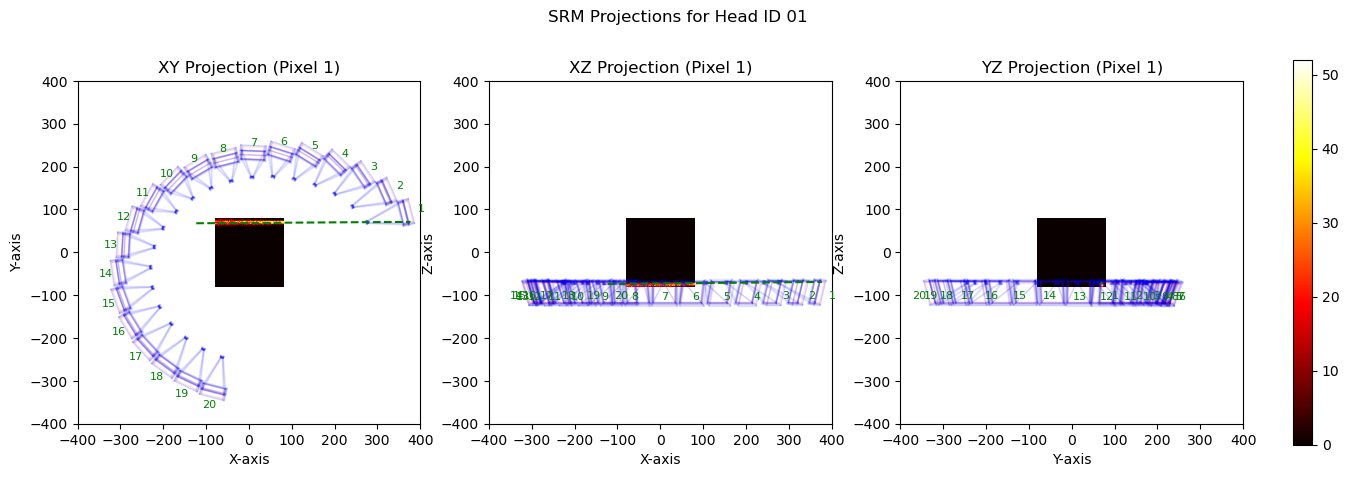

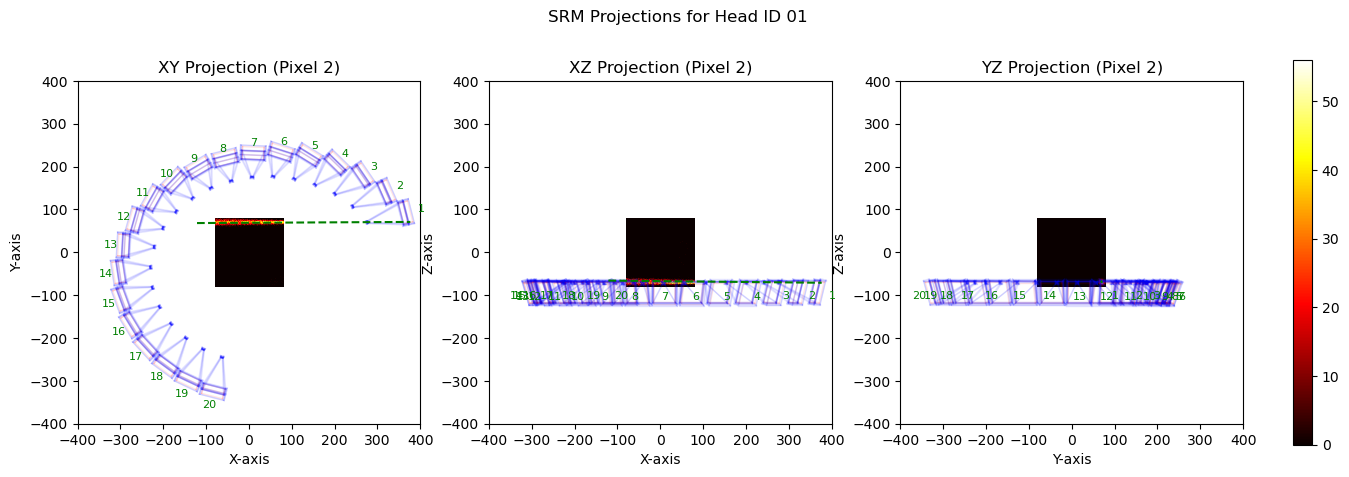

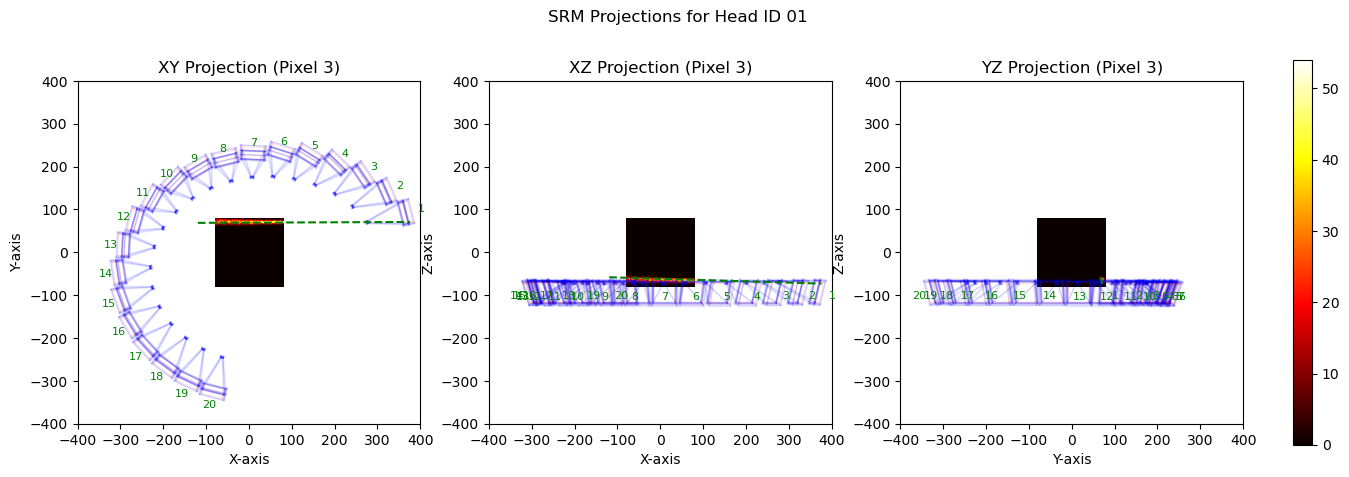

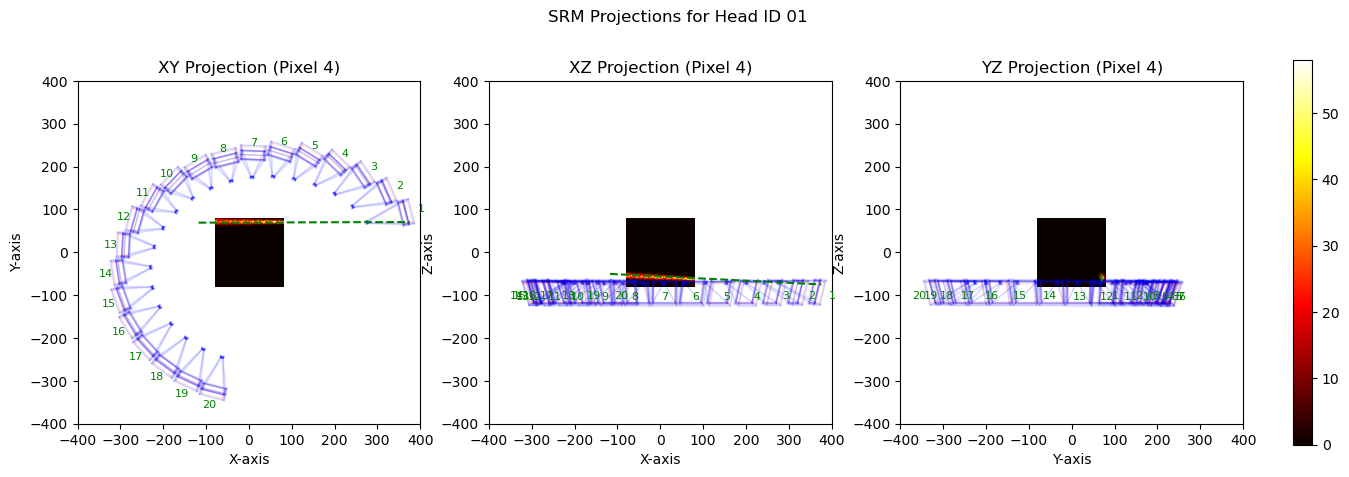

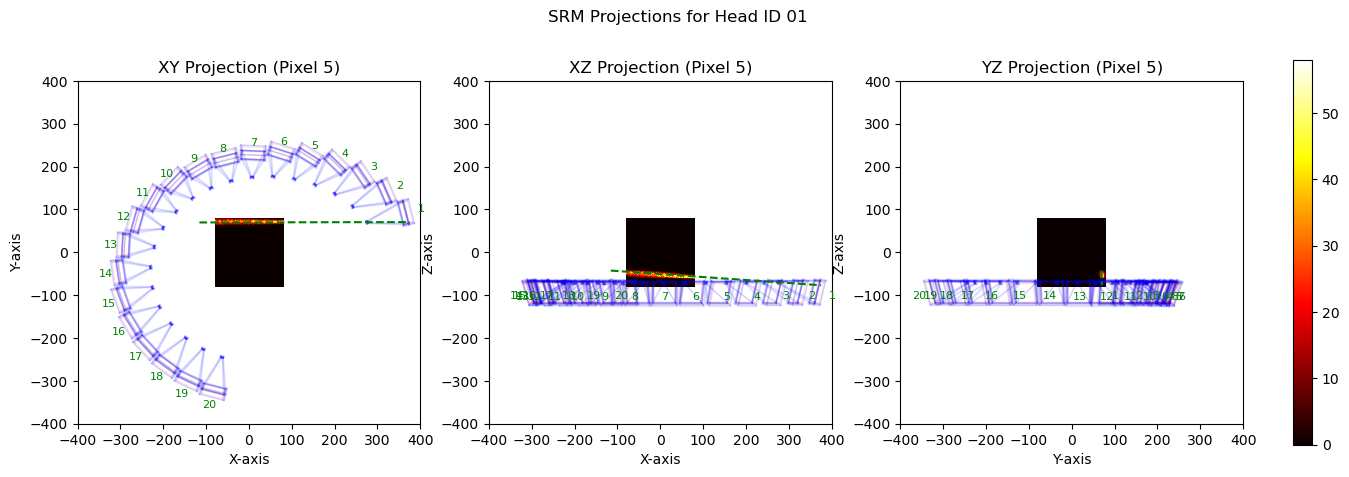

In [ ]:
from scipy.spatial.transform import Rotation as R

deg_z_array = dc_spect_geometry_config["azimuthal_angle_deg"]
deg_y_array = -dc_spect_geometry_config["polar_angle_deg"]
translation_array = dc_spect_geometry_config["detector_crystal_translation_mm"]
collimator_hole_coords_mm_np = dc_spect_geometry_config["collimator_hole_coords_mm_np"]
plt.ion()
for head_id in range(1):
    rotation = R.from_euler(
        "xyz", [0, deg_y_array[head_id], deg_z_array[head_id]], degrees=True
    )
    this_crystal_pixel_centers = (
        rotation.apply(pixel_centers) + translation_array[head_id]
    ).reshape(-1, 3)
    this_collimator_hole_center = collimator_hole_coords_mm_np[head_id]
    for pixel_id in range(6):
        fig, axs, ims = plot_sparse_3d_projections(
            ospool_sparse_srm[head_id][pixel_id],
            id=pixel_id + 1,
            prefix="Pixel",
            fov_size_mm=(160, 160, 160),
        )

        crystal_centers = []
        head_row_id = head_id // 20
        print(f"Processing Head ID {head_id + 1}, Row ID {head_row_id}")
        for crysta_id in range(head_row_id * 20 + 1, (head_row_id + 1) * 20 + 1):
            crystal_mesh_name = f"DetectorCrystal_{crysta_id}:0"
            crystal_mesh = get_mesh_by_name(meshes, crystal_mesh_name)
            collimator_mesh_name = f"Collimator_{crysta_id}:0"
            collimator_mesh = get_mesh_by_name(meshes, collimator_mesh_name)
            add_mesh_sharp_edges(
                axs, crystal_mesh, color="red", linewidth=1.0, alpha=0.1
            )
            add_mesh_sharp_edges(
                axs, collimator_mesh, color="blue", linewidth=1.0, alpha=0.1
            )
            axes_xyz_id = [[0, 1], [0, 2], [1, 2]]
            crystal_center = crystal_mesh.centroid
            crystal_centers.append(crystal_center)

            for axs_id in range(3):
                axs[axs_id].text(
                    crystal_center[axes_xyz_id[axs_id][0]] * 1.1,
                    crystal_center[axes_xyz_id[axs_id][1]] * 1.1,
                    f"{crysta_id}",
                    color="green",
                    fontsize=8,
                    ha="center",
                    va="center",
                )

            # principal_axes = np.stack([centers[19-(head_id % 20)],np.array([0,0,0])],axis=0)
        srm_pixel_id = pixel_id
        srm_pixel_id_x = srm_pixel_id // crystal_n_pixels[1]
        srm_pixel_id_y = srm_pixel_id % crystal_n_pixels[1]
        plot_pixel_id = srm_pixel_id_x * crystal_n_pixels[1] + (24-srm_pixel_id_y)
        plot_pixel_center = this_crystal_pixel_centers[plot_pixel_id]
        principal_axes = np.stack([this_collimator_hole_center, 
        plot_pixel_center], axis=0)
        principal_axes_vectors = principal_axes[1] - principal_axes[0]
        line_principal = np.array([principal_axes[0] - 4.0 * principal_axes_vectors, principal_axes[0] + principal_axes_vectors])
        for axs_id in range(3):
            axs[axs_id].plot(
                line_principal[:, axes_xyz_id[axs_id][0]],
                line_principal[:, axes_xyz_id[axs_id][1]],
                color="green",
                linewidth=1.5,
                linestyle="--",
                )
        fig.suptitle(f"SRM Projections for Head ID {(head_id + 1):02}")
plt.close(fig)  # Close the figure to free up memory


In [46]:
import uproot
import awkward as ak
import polars as pl

root_file_path = "pixel_singles_a_local_j_0.root"
# 1. Scan for valid trees
with uproot.open(root_file_path) as root_file:
    valid_trees = [
        f"{root_file_path}:Pixel_{i}_Singles"
        for i in range(1, 81)
        if f"Pixel_{i}_Singles" in root_file
    ]

# 2. Read into Awkward Array using multithreading
# library="ak" is uproot's default and fastest backend
ak_array = uproot.concatenate(valid_trees, library="ak", num_workers=32)

# 3. Convert to Polars via PyArrow (zero-copy transfer)
arrow_table = ak.to_arrow_table(ak_array)
df = pl.from_arrow(arrow_table)

print(f"Loaded Polars DataFrame with shape: {df.shape}")

Loaded Polars DataFrame with shape: (1289773, 15)


/tmp/ipykernel_1050807/2305694402.py:20: UserWarning: Extension type 'awkward' is not registered; loading as its storage type.

To avoid this warning, register the extension type or set environment variable 'POLARS_UNKNOWN_EXTENSION_TYPE_BEHAVIOR' to 'load_as_storage' or 'load_as_extension'.

In Polars 2.0, the default behavior will change to 'load_as_extension'.
  df = pl.from_arrow(arrow_table)


In [49]:
# Filter the DataFrame for events with TotalEnergyDeposit > 0.137 MeV
df_filtered = df.filter(df["TotalEnergyDeposit"] > 0.137)
# Make projection data from the simulated energy filtered data
df_projection = df_filtered.with_columns(
    df_filtered["PreStepUniqueVolumeID"]
    .str.split("_")
    .list.get(1)
    .cast(pl.Int32)
    .alias("CrystalID"),
    df_filtered["PreStepUniqueVolumeID"]
    .str.split("_")
    .list.get(-1)
    .cast(pl.Int32)
    .alias("PixelID"),
)
# add PixelID_X and PixelID_Y by dividing PixelID by 25 and taking the remainder
df_projection = df_projection.with_columns(
    (df_projection["PixelID"] // 25).alias("PixelID_X"),
    (df_projection["PixelID"] % 25).alias("PixelID_Y"),
)
# Print the range of CrystalID
crystal_id_min, crystal_id_max = (
    df_projection["CrystalID"].min(),
    df_projection["CrystalID"].max(),
)
pixel_id_min, pixel_id_max = (
    df_projection["PixelID"].min(),
    df_projection["PixelID"].max(),
)
print(f"CrystalID range: {crystal_id_min} to {crystal_id_max}")
print(f"PixelID range: {pixel_id_min} to {pixel_id_max}")

CrystalID range: 1 to 80
PixelID range: 0 to 624


Processing Head ID 1, Row ID 0
Processing Head ID 1, Row ID 0
Processing Head ID 1, Row ID 0
Processing Head ID 1, Row ID 0
Processing Head ID 1, Row ID 0
Processing Head ID 1, Row ID 0


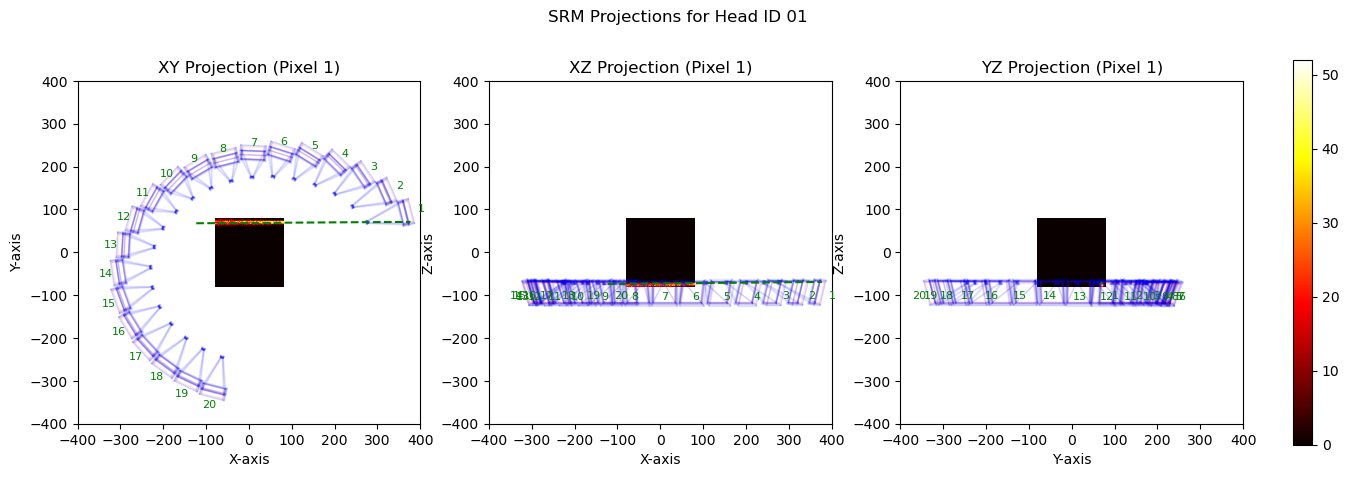

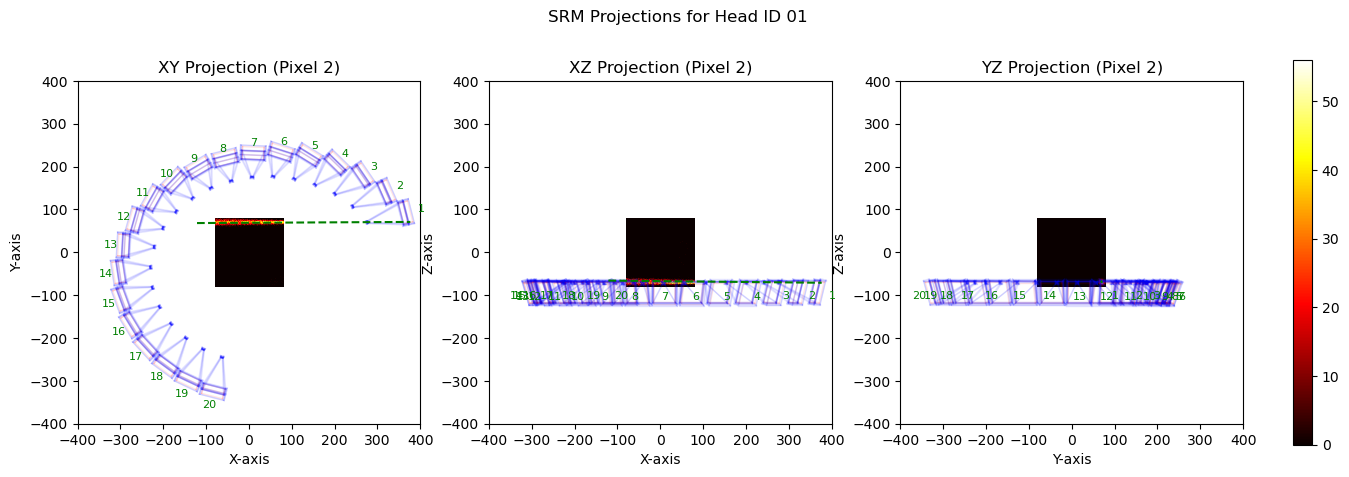

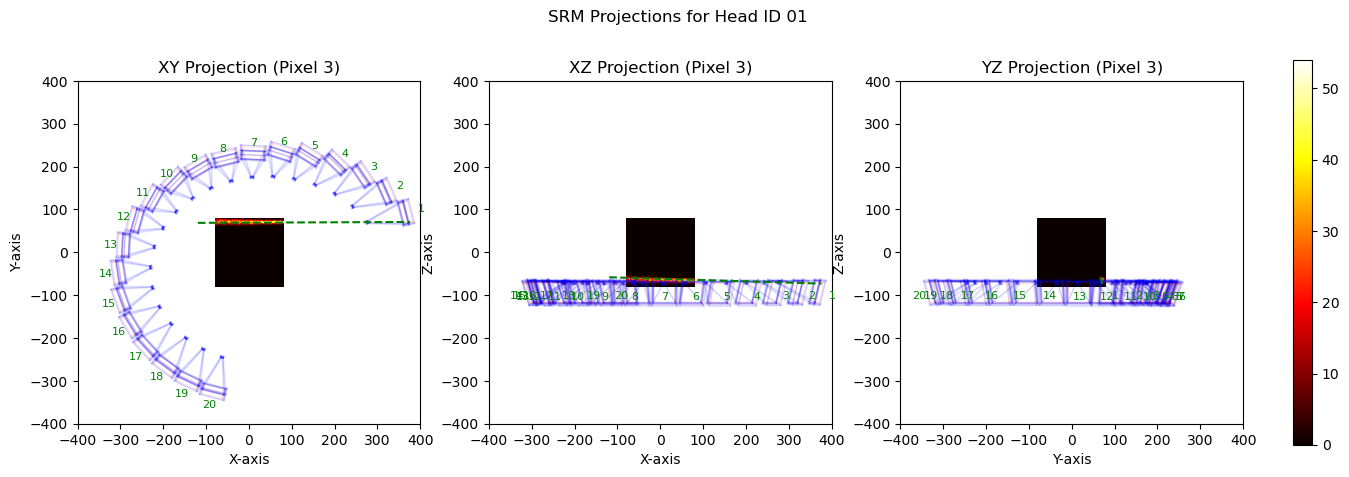

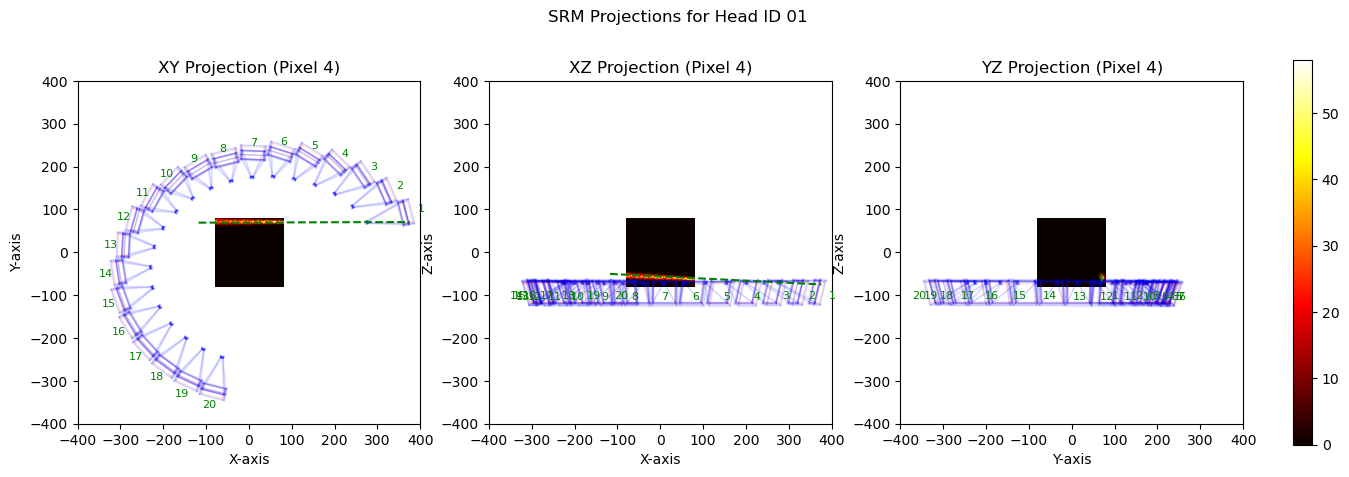

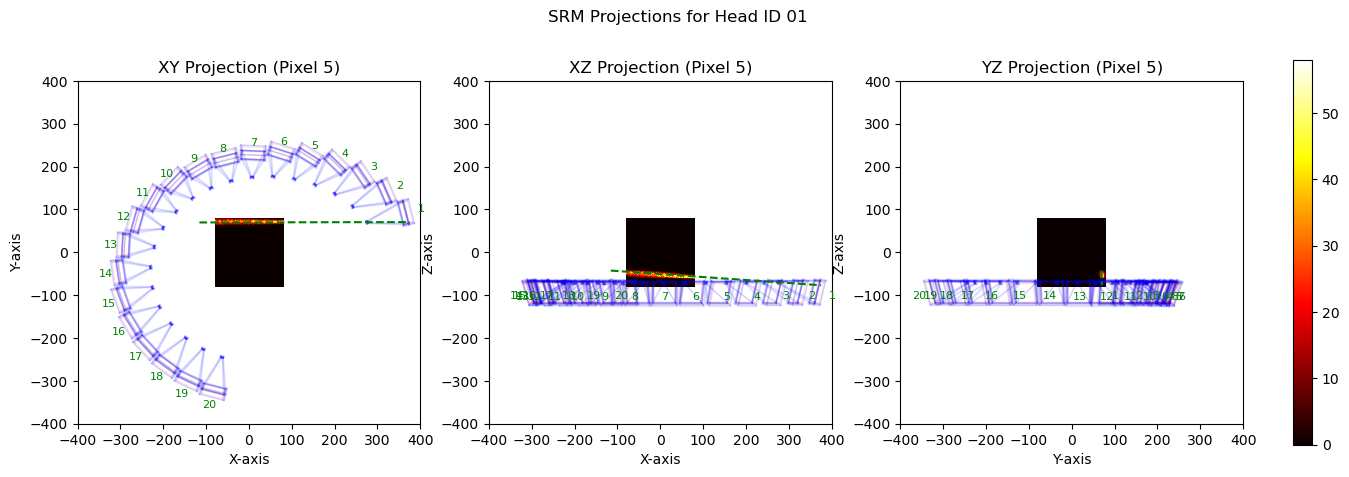

In [50]:

plt.ion()
for head_id in range(1):
    rotation = R.from_euler(
        "xyz", [0, deg_y_array[head_id], deg_z_array[head_id]], degrees=True
    )
    this_crystal_pixel_centers = (
        rotation.apply(pixel_centers) + translation_array[head_id]
    ).reshape(-1, 3)
    this_collimator_hole_center = collimator_hole_coords_mm_np[head_id]
    for pixel_id in range(6):
        fig, axs, ims = plot_sparse_3d_projections(
            ospool_sparse_srm[head_id][pixel_id],
            id=pixel_id + 1,
            prefix="Pixel",
            fov_size_mm=(160, 160, 160),
        )

        crystal_centers = []
        head_row_id = head_id // 20
        print(f"Processing Head ID {head_id + 1}, Row ID {head_row_id}")
        for crysta_id in range(head_row_id * 20 + 1, (head_row_id + 1) * 20 + 1):
            crystal_mesh_name = f"DetectorCrystal_{crysta_id}:0"
            crystal_mesh = get_mesh_by_name(meshes, crystal_mesh_name)
            collimator_mesh_name = f"Collimator_{crysta_id}:0"
            collimator_mesh = get_mesh_by_name(meshes, collimator_mesh_name)
            add_mesh_sharp_edges(
                axs, crystal_mesh, color="red", linewidth=1.0, alpha=0.1
            )
            add_mesh_sharp_edges(
                axs, collimator_mesh, color="blue", linewidth=1.0, alpha=0.1
            )
            axes_xyz_id = [[0, 1], [0, 2], [1, 2]]
            crystal_center = crystal_mesh.centroid
            crystal_centers.append(crystal_center)

            for axs_id in range(3):
                axs[axs_id].text(
                    crystal_center[axes_xyz_id[axs_id][0]] * 1.1,
                    crystal_center[axes_xyz_id[axs_id][1]] * 1.1,
                    f"{crysta_id}",
                    color="green",
                    fontsize=8,
                    ha="center",
                    va="center",
                )

            # principal_axes = np.stack([centers[19-(head_id % 20)],np.array([0,0,0])],axis=0)

        pixel_singles_df = df_projection.filter((pl.col("CrystalID") == head_id + 1) & (pl.col("PixelID") == pixel_id))
        if pixel_singles_df.height == 0:
            print(f"PixelID {pixel_id + 1}: no singles found, skipping.")
            continue

        detected_singles_coords = pixel_singles_df.select(
            ["PostPosition_X", "PostPosition_Y", "PostPosition_Z"]
        ).to_numpy()
        detected_singles_center = detected_singles_coords.mean(axis=0)
        principal_axes = np.stack([this_collimator_hole_center, detected_singles_center], axis=0)
        principal_axes_vectors = principal_axes[1] - principal_axes[0]
        line_principal = np.array([principal_axes[0] - 4.0 * principal_axes_vectors, principal_axes[0] + principal_axes_vectors])
        for axs_id in range(3):
            axs[axs_id].plot(
                line_principal[:, axes_xyz_id[axs_id][0]],
                line_principal[:, axes_xyz_id[axs_id][1]],
                color="green",
                linewidth=1.5,
                linestyle="--",
                )
        fig.suptitle(f"SRM Projections for Head ID {(head_id + 1):02}")
plt.close(fig)  # Close the figure to free up memory
    

